# EDA for New Data

This EDA will be broken down into three sections: general data exploration, univariate analysis, and multivariate analysis.

## Missing Values and Duplicates


In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# data reading in
raw_df = pd.read_csv("data/Sleep_health_and_lifestyle_dataset.csv")
raw_df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [ ]:
# missing values

raw_df.isna().sum()

# duplicate values


np.int64(242)

So it seems as though this data is pretty clean in terms of missing values. It is therefore either synthetically generated or has already gone through pre-processing. I could turn those NAs in Sleep Disorder to be a "None" class, but I will address that later.

In terms of duplcates, it seems that when taking the person id away, many observations are duplicated (242/374). This is quite concerning as things like heart rate, age, occupation, blood pressure, etc. are difficult to have duplicated exactly. I am wondering whether this is an error in the data.

## Univariate Analysis

### Response Variables

Three variables of interest are Sleep Duration, Quality of Sleep, and Stress Level. I will observe their distributions and identify extreme observations/ potential outliers.

Sleep Duration
7.2    36
6.0    31
7.8    28
6.5    26
6.1    25
7.7    24
6.6    20
7.1    19
8.1    15
7.3    14
8.4    14
8.0    13
6.3    13
8.5    13
6.2    12
8.2    11
7.6    10
6.4     9
7.9     7
8.3     5
7.4     5
6.7     5
7.5     5
6.8     5
5.9     4
6.9     3
5.8     2
Name: count, dtype: int64

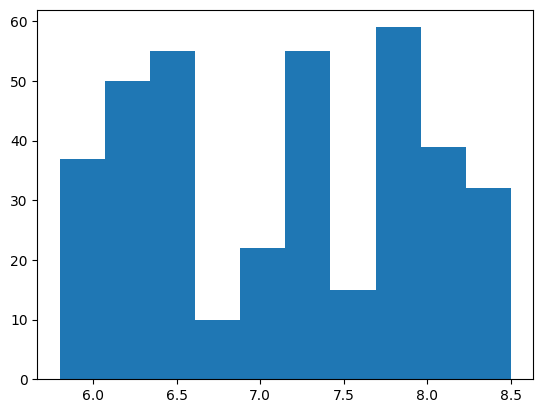

In [12]:
# Sleep Duration:

plt.hist(raw_df['Sleep Duration'])
raw_df["Sleep Duration"].value_counts()

What is concerning with this variable after plotting the histogram and looking more indepth into the individual values is two-fold. Firstly, the distribution of sleep duration looks trimodal within the histogram. This defers from our previous dataset, where observations were distributed normally. Secondly, the values of sleep duration are more specific than typically expected of real people to document. Generally, people like to round, and so it would be expected to see whole or .5 rounding. Yet, the top most documented duration ends with .2. While this could be attributed to sleep tracking devices, we might then expect missing data occurring, attributed to study participants neglecting to wear their device.

0      6
1      6
2      6
3      4
4      4
      ..
369    9
370    9
371    9
372    9
373    9
Name: Quality of Sleep, Length: 374, dtype: int64

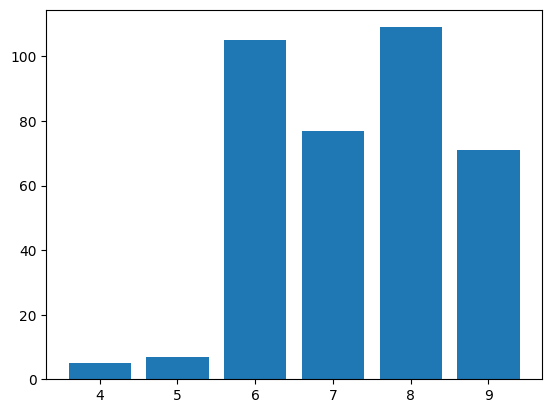

In [39]:
# Quality of Sleep

plt.bar(raw_df["Quality of Sleep"].value_counts().index, raw_df["Quality of Sleep"].value_counts().values)
raw_df['Quality of Sleep']


Quality of sleep is definitely plotted on a scale. The data documentation does not specify what kind of scale or what the ranges of the original scale are. For the purposes of my analysis, I will have to make some assumptions based on what the other response variables reflect.

Stress Level
3    71
8    70
4    70
5    67
7    50
6    46
Name: count, dtype: int64

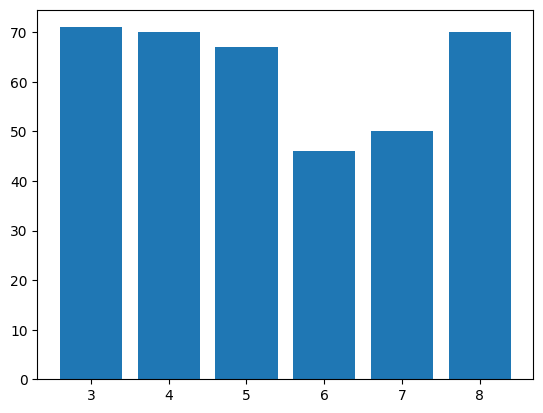

In [38]:
# stress level

plt.bar(raw_df['Stress Level'].value_counts().index, raw_df['Stress Level'].value_counts().values)
raw_df['Stress Level'].value_counts()

The same problems with quality of sleep arise with stress level. This seems to be set at a scale as well, but no description of the scale or the range is given. To perhaps gain a better understanding of these two variables, I will take a look at the sleep disorder variable to see if I can identify patterns.

In [34]:
# Sleep Disorder

raw_df[raw_df["Sleep Disorder"]=="Insomnia"]

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
18,19,Female,29,Nurse,6.5,5,40,7,Normal Weight,132/87,80,4000,Insomnia
31,32,Female,30,Nurse,6.4,5,35,7,Normal Weight,130/86,78,4100,Insomnia
67,68,Male,33,Doctor,6.0,6,30,8,Normal,125/80,72,5000,Insomnia
...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,309,Female,52,Accountant,6.6,7,45,7,Overweight,130/85,72,6000,Insomnia
309,310,Female,52,Accountant,6.6,7,45,7,Overweight,130/85,72,6000,Insomnia
310,311,Female,52,Accountant,6.6,7,45,7,Overweight,130/85,72,6000,Insomnia
311,312,Female,52,Accountant,6.6,7,45,7,Overweight,130/85,72,6000,Insomnia


From this data and some logical deductions (I still may be wrong), I am going to assume that the scale of both Quality of Sleep and Stress Level are from 1-10. Additionally, the higher the value, the higher the quality of sleep or stress level respectively. Thus, a 1 would represent low sleep quality under the Quality of Sleep variable or a low stress level under the Stress Level variable.

Assuming these scales and after observing the data, I see much class imbalances (if we were to use these as classes). We could also keep them as numeric to preserve scale/ order.

I also think that the sleep disorders would be good to explore for patterns. This could turn into a response variable for a classification hypothesis.

<BarContainer object of 2 artists>

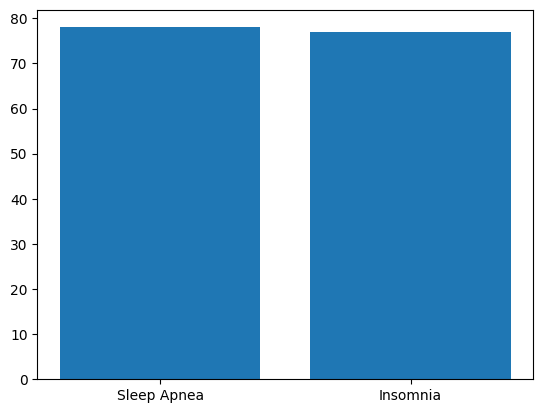

In [37]:
# Exploring Sleep disorder
raw_df['Sleep Disorder'].value_counts()
plt.bar(raw_df['Sleep Disorder'].value_counts().index, raw_df['Sleep Disorder'].value_counts().values)

### Other Variables

In [50]:
raw_df.columns

# age
#plt.hist(raw_df.Age) 
# # good distribution of ages overall, though a bit uneven

# occupation
#plt.bar(raw_df.Occupation.value_counts().index, raw_df.Occupation.value_counts().values) 
# # it is not pretty, but gets the job done for now. seems like there are a range of different occupations
# # some I would classify as high stress


Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

While I was going to wait and do this in a separate script for easier documentation, the variable names having spaces are quite cumbersome to work with, and frankly, against good variable naming conventions. Thus, the following section will change the names of the variables that have spaces in the names. After doing so, I will continue univariate analysis of the rest of the variables.

### Variable Renaming

In [53]:
rename_cols = {
    "Sleep Duration": "sleep_duration",
    "Sleep Disorder": "sleep_disorder",
    "Stress Level": "stress_level",
    "Quality of Sleep": "sleep_quality",
    "Physical Activity Level": "physical_activity_level",
    "Age": "age",
    "Occupation": "occupation",
    "Person ID": "person_id",
    "Gender": "gender",
    "BMI Category": "bmi_category",
    "Blood Pressure": "blood_pressure",
    "Heart Rate": "heart_rate",
    "Daily Steps": "daily_steps",
}
raw_df.rename(columns=rename_cols, inplace=True)

# check for correctness of renaming
raw_df.columns

Index(['person_id', 'gender', 'age', 'occupation', 'sleep_duration',
       'sleep_quality', 'physical_activity_level', 'stress_level',
       'bmi_category', 'blood_pressure', 'heart_rate', 'daily_steps',
       'sleep_disorder'],
      dtype='object')